In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from scipy.spatial import ConvexHull
import matplotlib.patches as patches
from scipy.stats import kde

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_clusters(data, cluster_labels, n_components=2):
    """
    Perform PCA on data and plot clusters in 2D or 3D with green, red, and blue colors.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform PCA on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    reduced_data = pca.fit_transform(data)
    
    # Define specific colors for clusters
    unique_labels = np.unique(cluster_labels)
    colors = ['green', 'red', 'blue']  # Limited to green, red, and blue

    if len(unique_labels) > len(colors):
        raise ValueError("Too many clusters; only green, red, and blue colors are available.")
    
    if n_components == 2:
      plt.figure(figsize=(5, 4))
      for label, color in zip(unique_labels, colors):
        cluster_data = reduced_data[cluster_labels == label]
        mean = np.mean(cluster_data, axis=0)
        std = np.std(cluster_data, axis=0)
        radius = 2 * np.max(std)  # Adjust the radius as needed

        circle = plt.Circle(mean, radius, color=color, alpha=0.2, fill=False)
        plt.gca().add_patch(circle)

        plt.scatter(reduced_data[cluster_labels == label, 0], 
                    reduced_data[cluster_labels == label, 1], 
                    color=color, label=f'C_{label+1}'
    .replace('_1', '₁')
    .replace('_2', '₂')
    .replace('_3', '₃'), s=50)
    
    # Plotting
    if n_components == 2:
        plt.figure(figsize=(5, 4))
        for label, color in zip(unique_labels, colors):
            plt.scatter(reduced_data[cluster_labels == label, 0], 
                        reduced_data[cluster_labels == label, 1], 
                        color=color, label=f'C_{label+1}'
    .replace('_1', '₁')
    .replace('_2', '₂')
    .replace('_3', '₃'), s=50)
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        # plt.title('2D PCA Clusters')
        plt.legend()
        plt.show()
    
    elif n_components == 3:
        fig = plt.figure(figsize=(10, 4))
        ax = fig.add_subplot(111, projection='3d')
        for label, color in zip(unique_labels, colors):
            ax.scatter(reduced_data[cluster_labels == label, 0], 
                       reduced_data[cluster_labels == label, 1], 
                       reduced_data[cluster_labels == label, 2], 
                       color=color, label=f'C_{label+1}', s=50)
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        # ax.set_title('3D PCA Clusters')
        ax.legend()
        plt.show()


In [21]:
def plot_umap_clusters(data, cluster_labels, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    """
    Perform UMAP on data and plot clusters in 2D or 3D.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform UMAP on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of UMAP components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    - n_neighbors: int, optional (default=15)
      The size of local neighborhood (in terms of number of neighboring sample points) for UMAP.
    - min_dist: float, optional (default=0.1)
      The minimum distance apart that points are allowed to be in the UMAP embedding space.
    - random_state: int, optional (default=42)
      Random state for reproducibility of results.
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform UMAP
    umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, 
                           min_dist=min_dist, random_state=random_state)
    reduced_data = umap_model.fit_transform(data)
    
    # Plotting
    if n_components == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis', s=50)
        plt.xlabel('UMAP Component 1')
        plt.ylabel('UMAP Component 2')
        plt.title('2D UMAP Clusters')
        plt.colorbar(label='Cluster Label')
        plt.show()
    
    elif n_components == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(reduced_data[:, 0], reduced_data[:, 1], reduced_data[:, 2], 
                             c=cluster_labels, cmap='viridis', s=50)
        ax.set_xlabel('UMAP Component 1')
        ax.set_ylabel('UMAP Component 2')
        ax.set_zlabel('UMAP Component 3')
        ax.set_title('3D UMAP Clusters')
        fig.colorbar(scatter, ax=ax, label='Cluster Label')
        plt.show()

In [22]:
def plot_tsne_clusters(data, cluster_labels, n_components=2, perplexity=30, learning_rate=200, random_state=42):
    """
    Perform t-SNE on data and plot clusters in 2D or 3D.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform t-SNE on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of t-SNE components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    - perplexity: float, optional (default=30)
      Perplexity parameter for t-SNE, affecting the balance between local and global aspects.
    - learning_rate: float, optional (default=200)
      The learning rate for t-SNE.
    - random_state: int, optional (default=42)
      Random state for reproducibility of results.
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, 
                learning_rate=learning_rate, random_state=random_state)
    reduced_data = tsne.fit_transform(data)
    
    # Plotting
    if n_components == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis', s=50)
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.title('2D t-SNE Clusters')
        plt.colorbar(label='Cluster Label')
        plt.show()
    
    elif n_components == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(reduced_data[:, 0], reduced_data[:, 1], reduced_data[:, 2], 
                             c=cluster_labels, cmap='viridis', s=50)
        ax.set_xlabel('t-SNE Component 1')
        ax.set_ylabel('t-SNE Component 2')
        ax.set_zlabel('t-SNE Component 3')
        ax.set_title('3D t-SNE Clusters')
        fig.colorbar(scatter, ax=ax, label='Cluster Label')
        plt.show()

In [6]:
data = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 53 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [7]:
normalized_data = normalize(data[data.columns[:28]])

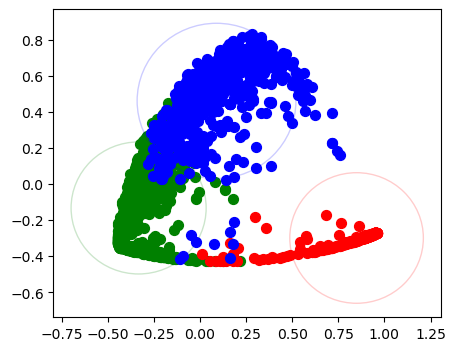

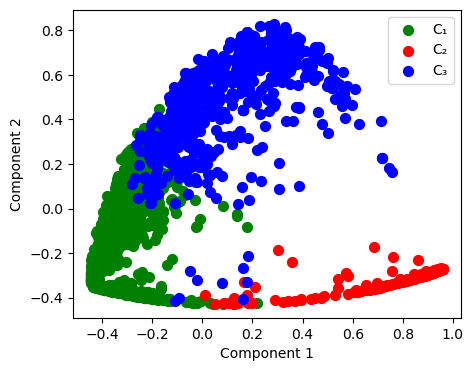

In [10]:
plot_pca_clusters(normalized_data, data['Majority Voting Label'], 2)

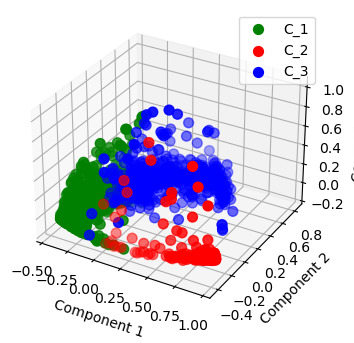

In [82]:
plot_pca_clusters(normalized_data, data['Majority Voting Label'], 3)

C:\Users\mmia43\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


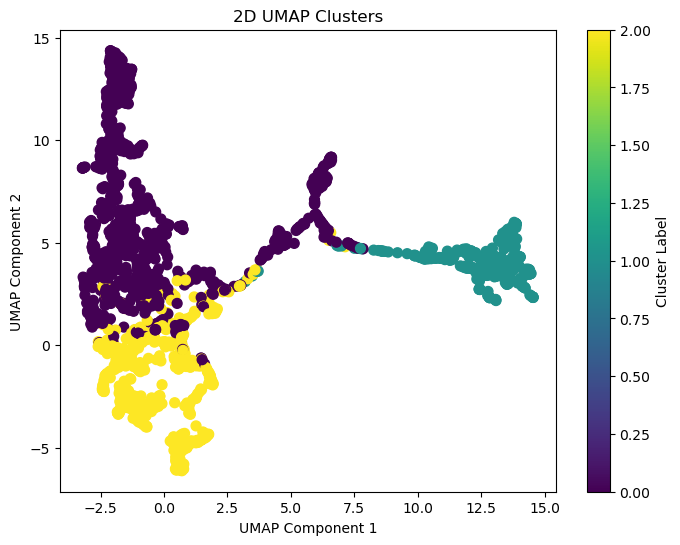

In [23]:
plot_umap_clusters(normalized_data, data['Majority Voting Label'], 2)

C:\Users\mmia43\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


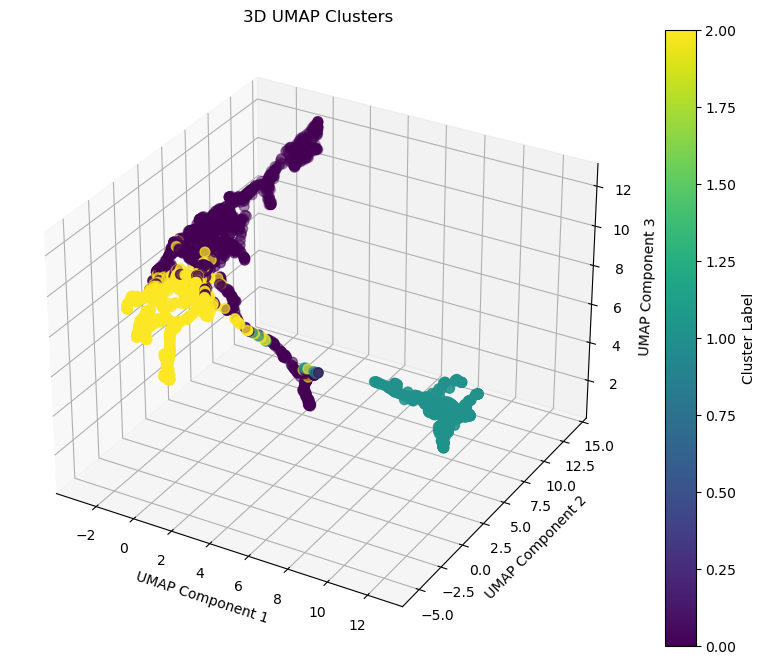

In [24]:
plot_umap_clusters(normalized_data, data['Majority Voting Label'], 3)

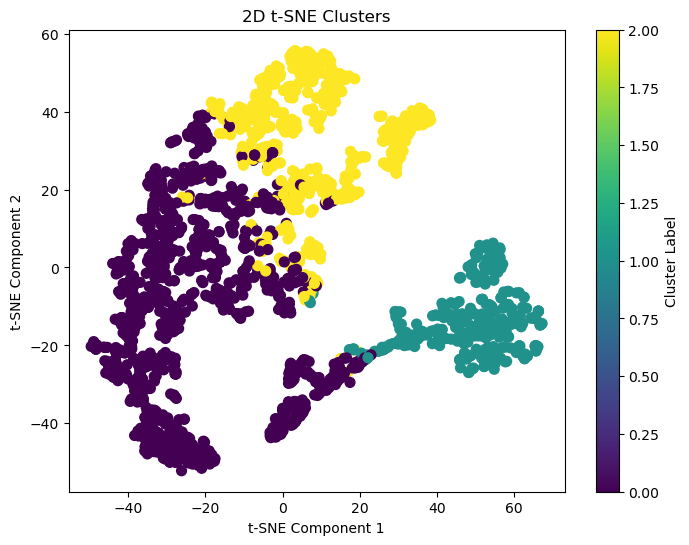

In [25]:
plot_tsne_clusters(normalized_data, data['Majority Voting Label'], 2)

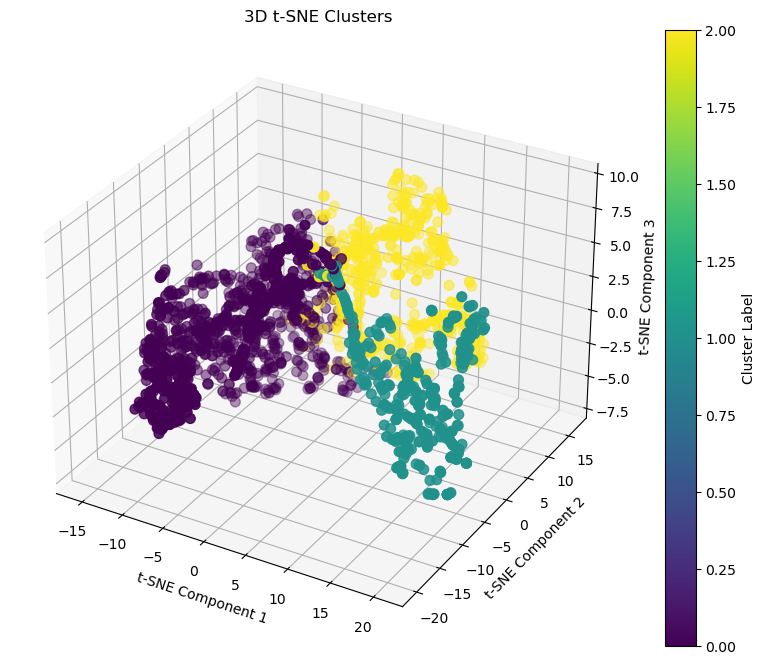

In [26]:
plot_tsne_clusters(normalized_data, data['Majority Voting Label'], 3)

In [27]:
from sklearn.manifold import TSNE
import plotly.express as px

def plot_tsne_clusters_interactive(data, cluster_labels, n_components=2, perplexity=30, learning_rate=200, random_state=42):
    """
    Perform t-SNE on data and plot clusters in 2D or 3D with interactivity.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform t-SNE on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of t-SNE components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    - perplexity: float, optional (default=30)
      Perplexity parameter for t-SNE, affecting the balance between local and global aspects.
    - learning_rate: float, optional (default=200)
      The learning rate for t-SNE.
    - random_state: int, optional (default=42)
      Random state for reproducibility of results.
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, 
                learning_rate=learning_rate, random_state=random_state)
    reduced_data = tsne.fit_transform(data)
    
    # Plotting
    if n_components == 2:
        fig = px.scatter(x=reduced_data[:, 0], y=reduced_data[:, 1], color=cluster_labels,
                         labels={'color': 'Cluster Label'}, title="2D t-SNE Clusters")
        fig.update_layout(xaxis_title="t-SNE Component 1", yaxis_title="t-SNE Component 2")
    
    elif n_components == 3:
        fig = px.scatter_3d(x=reduced_data[:, 0], y=reduced_data[:, 1], z=reduced_data[:, 2], 
                            color=cluster_labels, labels={'color': 'Cluster Label'},
                            title="3D t-SNE Clusters")
        fig.update_layout(scene=dict(
            xaxis_title="t-SNE Component 1",
            yaxis_title="t-SNE Component 2",
            zaxis_title="t-SNE Component 3"))
    
    fig.show()


In [28]:
plot_tsne_clusters_interactive(normalized_data, data['Majority Voting Label'], 2)

In [29]:
plot_tsne_clusters_interactive(normalized_data, data['Majority Voting Label'], 3)

In [54]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import pandas as pd

def plot_pca_clusters_interactive(data, cluster_labels, n_components=2):
    """
    Perform PCA on data and plot clusters in 2D or 3D with interactivity using green, red, and blue.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform PCA on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    reduced_data = pca.fit_transform(data)
    
    # Define specific colors for clusters
    unique_labels = pd.Series(cluster_labels).unique()
    if len(unique_labels) > 3:
        raise ValueError("Too many clusters; only green, red, and blue are supported.")
    color_map = {label: color for label, color in zip(unique_labels, ['green', 'blue', 'red'])}
    cluster_colors = [color_map[label] for label in cluster_labels]

    # Create a DataFrame for Plotly
    pca_df = pd.DataFrame(reduced_data, columns=[f'Component {i+1}' for i in range(n_components)])
    pca_df['Cluster'] = cluster_labels
    pca_df['Color'] = cluster_colors

    # Plotting
    if n_components == 2:
        fig = go.Figure()
        for label in unique_labels:
            cluster_data = pca_df[pca_df['Cluster'] == label]
            fig.add_trace(go.Scatter(
                x=cluster_data['Component 1'],
                y=cluster_data['Component 2'],
                mode='markers',
                marker=dict(color=color_map[label], size=8),
                name=f'Cluster {label+1}'
            ))
        fig.update_layout(
            title="2D PCA Clusters",
            xaxis_title="Component 1",
            yaxis_title="Component 2"
        )
    
    elif n_components == 3:
        fig = go.Figure()
        for label in unique_labels:
            cluster_data = pca_df[pca_df['Cluster'] == label]
            fig.add_trace(go.Scatter3d(
                x=cluster_data['Component 1'],
                y=cluster_data['Component 2'],
                z=cluster_data['Component 3'],
                mode='markers',
                marker=dict(color=color_map[label], size=4),
                name=f'Cluster {label+1}'
            ))
        fig.update_layout(
            title="3D PCA Clusters",
            scene=dict(
                xaxis_title="Component 1",
                yaxis_title="Component 2",
                zaxis_title="Component 3"
            )
        )
    
    fig.show()


In [55]:
plot_pca_clusters_interactive(normalized_data, data['Majority Voting Label'], 2)

In [56]:
plot_pca_clusters_interactive(normalized_data, data['Majority Voting Label'], 3)

In [32]:
import umap
import plotly.express as px

def plot_umap_clusters_interactive(data, cluster_labels, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    """
    Perform UMAP on data and plot clusters in 2D or 3D with interactivity.

    Parameters:
    - data: 2D array-like, shape (n_samples, n_features)
      The data to perform UMAP on.
    - cluster_labels: array-like, shape (n_samples,)
      The cluster labels for each data point.
    - n_components: int, optional (default=2)
      Number of UMAP components for dimensionality reduction (2 for 2D plot, 3 for 3D plot).
    - n_neighbors: int, optional (default=15)
      The size of local neighborhood (in terms of number of neighboring sample points) for UMAP.
    - min_dist: float, optional (default=0.1)
      The minimum distance apart that points are allowed to be in the UMAP embedding space.
    - random_state: int, optional (default=42)
      Random state for reproducibility of results.
    """
    # Validate the number of components
    if n_components not in [2, 3]:
        raise ValueError("n_components must be 2 or 3 for plotting.")
    
    # Perform UMAP
    umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, 
                           min_dist=min_dist, random_state=random_state)
    reduced_data = umap_model.fit_transform(data)
    
    # Plotting
    if n_components == 2:
        fig = px.scatter(x=reduced_data[:, 0], y=reduced_data[:, 1], color=cluster_labels,
                         labels={'color': 'Cluster Label'}, title="2D UMAP Clusters")
        fig.update_layout(xaxis_title="UMAP Component 1", yaxis_title="UMAP Component 2")
    
    elif n_components == 3:
        fig = px.scatter_3d(x=reduced_data[:, 0], y=reduced_data[:, 1], z=reduced_data[:, 2], 
                            color=cluster_labels, labels={'color': 'Cluster Label'},
                            title="3D UMAP Clusters")
        fig.update_layout(scene=dict(
            xaxis_title="UMAP Component 1",
            yaxis_title="UMAP Component 2",
            zaxis_title="UMAP Component 3"))
    
    fig.show()


In [34]:
plot_umap_clusters_interactive(data[data.columns[:28]], data['Majority Voting Label'], 2)

C:\Users\mmia43\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [33]:
plot_umap_clusters_interactive(data[data.columns[:28]], data['Majority Voting Label'], 3)

C:\Users\mmia43\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

